In [ ]:
# Run from the repository's notebooks/ directory.
# Original Google Colab drive mount removed for local reproducibility;
# see docs/reproducibility.md for the execution-order table.


Mounted at /content/drive


In [ ]:
!pip install -q plotly

In [ ]:

import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


In [ ]:
import os

candidate_paths = [
    "../data/derived/worldcup2022_passes.csv",
]

csv_path = next((p for p in candidate_paths if os.path.exists(p)), None)

if csv_path is None:
    raise FileNotFoundError(
        "Could not find 3812_passes_raw.csv in any of: "
        f"{candidate_paths}. Current working directory is {os.getcwd()} "
        f"— files here: {os.listdir('.')}"
    )

df = pd.read_csv(csv_path)
print(f"Loaded: {csv_path}")

Loaded: /content/drive/MyDrive/Research Projects Data/worldcup2022_passes.csv


In [ ]:
print(df.columns.tolist())


['match_id', 'game_event_id', 'possession_event_id', 'period', 'start_time', 'end_time', 'event_time', 'game_clock', 'team_id', 'passer_id', 'receiver_id', 'pass_success', 'pass_outcome_code', 'pass_outcome', 'pass_type', 'pass_category', 'frame_count', 'frame_selection', 'valid_coordinate_count', 'curve_status', 'path_length_3d', 'chord_length_3d', 'straightness_3d', 'max_deviation_3d', 'max_deviation_x', 'max_deviation_y', 'max_deviation_z', 'x_range', 'y_range', 'z_range', 'frame_numbers', 'frame_timestamps_ms', 'ball_x', 'ball_y', 'ball_z', 'ball_visibility']


## Curvature Metric: True 3D Curvature

The previous version computed curvature separately in each coordinate plane
(YZ, XZ, XY) using the 2D curvature formula on each pair of axes. That splits
a single physical bend in the ball's flight across three numbers, and a pass
that curves diagonally (e.g. partly sideways, partly up) doesn't cleanly show
up in any one of them.

This version uses the actual 3D curvature of the flight path instead:

    kappa(t) = |r'(t) x r''(t)| / |r'(t)|^3

where `r'(t)` is the 3D velocity vector and `r''(t)` is the 3D acceleration
vector, `x` is the full 3D cross product, and `|.|` is vector magnitude. This
is the standard definition of curvature for a curve in 3D space: how sharply
the path is bending at each instant, independent of which axes that bending
happens across. It's a magnitude, so it's always >= 0 (no sign / direction).

From `kappa(t)` computed at every valid frame of a pass, three summary
numbers are kept per pass:

- **`curvature_3d_score`** - arc-length-weighted average curvature. Frames
  aren't evenly spaced in distance traveled (the ball speeds up and slows
  down), so this weights each frame's curvature by how much distance was
  actually covered around it, instead of letting slow-moving segments
  dominate just because they were recorded in more frames. This is the
  single best "how curved was this pass overall" number.
- **`curvature_3d_mean`** - simple unweighted mean of `kappa(t)` across
  valid frames.
- **`curvature_3d_median`** - median of `kappa(t)` across valid frames,
  robust to a single noisy/spiky frame.

In [ ]:
import os
import ast
import numpy as np
import pandas as pd


def parse_list(value):
    if value is None or pd.isna(value):
        return []

    if isinstance(value, (list, tuple, np.ndarray)):
        return list(value)

    value = str(value).strip()

    if not value or value.lower() in {"nan", "none", "null", "na", "n/a"}:
        return []

    try:
        parsed = ast.literal_eval(value)
        return list(parsed) if isinstance(parsed, (list, tuple, np.ndarray)) else []
    except (ValueError, SyntaxError):
        return []


def calculate_curvature_3d(timestamps_ms, x, y, z):
    """
    Normalized 3D curvature based on the area between the actual ball
    trajectory and the straight-line chord connecting its start and end points.

    The straight-line distance is:

        D = ||r_end - r_start||

    The perpendicular distance of each trajectory point from the chord is:

        d_i = ||(r_i - r_start) x (r_end - r_start)|| / D

    The deviation area is estimated using trapezoidal integration along
    the actual 3D trajectory:

        A_dev = integral d(s) ds

    The final normalized curvature measure is:

        C_3D = A_dev / D^2

    Returns [normalized_curvature, deviation_area, straight_line_distance].
    """
    t = np.asarray(timestamps_ms, dtype=float)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    n = min(len(t), len(x), len(y), len(z))

    if n < 2:
        return [np.nan, np.nan, np.nan]

    t = t[:n] / 1000.0
    x = x[:n]
    y = y[:n]
    z = z[:n]

    valid = (
        np.isfinite(t)
        & np.isfinite(x)
        & np.isfinite(y)
        & np.isfinite(z)
    )

    if valid.sum() < 2:
        return [np.nan, np.nan, np.nan]

    t = t[valid]
    x = x[valid]
    y = y[valid]
    z = z[valid]

    if np.any(np.diff(t) <= 0):
        return [np.nan, np.nan, np.nan]

    # 3D trajectory points
    points = np.column_stack((x, y, z))

    # Start and end points of the trajectory
    start_point = points[0]
    end_point = points[-1]

    # Straight-line vector between start and end
    chord_vector = end_point - start_point
    chord_length = np.linalg.norm(chord_vector)

    if chord_length <= 1e-12:
        return [np.nan, np.nan, np.nan]

    # Perpendicular distance of every trajectory point from the
    # straight line connecting the start and end points
    relative_points = points - start_point

    cross_product = np.cross(
        relative_points,
        chord_vector
    )

    distances = np.linalg.norm(cross_product, axis=1) / chord_length

    # 3D distance traveled between consecutive trajectory points
    segment_vectors = np.diff(points, axis=0)
    segment_lengths = np.linalg.norm(segment_vectors, axis=1)

    # Area between the actual trajectory and the straight-line chord.
    # Trapezoidal integration of perpendicular deviation with respect
    # to the actual trajectory arc length.
    deviation_area = np.sum(
        0.5 * (distances[:-1] + distances[1:]) * segment_lengths
    )

    # Normalize by the squared straight-line distance
    normalized_curvature = deviation_area / (chord_length ** 2)

    return [
        normalized_curvature,
        deviation_area,
        chord_length
    ]


def calculate_row_curvature(row):
    timestamps = parse_list(row["frame_timestamps_ms"])
    x = parse_list(row["ball_x"])
    y = parse_list(row["ball_y"])
    z = parse_list(row["ball_z"])

    return calculate_curvature_3d(timestamps, x, y, z)




curvature_columns = [
    "curvature_3d_normalized",
    "curvature_3d_deviation_area",
    "curvature_3d_straight_line_length"
]

df[curvature_columns] = df.apply(
    calculate_row_curvature,
    axis=1,
    result_type="expand"
)

df.to_csv("../data/derived/3812_passes_with_curvature.csv", index=False)

In [ ]:
df.to_csv("../data/derived/3812_passes_with_curvature.csv", index=False)

In [ ]:
curved_passes[curved_passes["curvature_3d_normalized"] > 1]

,match_id,game_event_id,possession_event_id,period,start_time,end_time,event_time,game_clock,team_id,passer_id,receiver_id,pass_success,pass_outcome_code,pass_outcome,pass_type,pass_category,frame_count,frame_selection,valid_coordinate_count,curve_status,path_length_3d,chord_length_3d,straightness_3d,max_deviation_3d,max_deviation_x,max_deviation_y,max_deviation_z,x_range,y_range,z_range,frame_numbers,frame_timestamps_ms,ball_x,ball_y,ball_z,ball_visibility,curvature_3d_normalized,curvature_3d_deviation_area,curvature_3d_straight_line_length
58,3812,6498167,6374496,1,447.881,452.186,452.186,05:11,372,3848,13901.0,True,C,complete,S,normal,130,event_interval,130,measured,7.208077,1.283822,0.178109,1.527940,0.880543,1.057752,0.695271,1.38,1.51,1.24,"[13423,13424,13425,13426,13427,13428,13429,134...","[447881.215,447914.581,447947.948,447981.315,4...","[13.02,13.05,13.07,13.1,13.13,13.15,13.18,13.2...","[-31.02,-31.06,-31.11,-31.15,-31.19,-31.23,-31...","[0.14,0.14,0.14,0.13,0.13,0.13,0.13,0.14,0.14,...","[""ESTIMATED"",""ESTIMATED"",""ESTIMATED"",""ESTIMATE...",2.604001,4.291915,1.283822
92,3812,6498457,6374784,1,642.743,644.244,644.244,08:23,366,8034,84.0,True,C,complete,S,normal,44,event_interval,44,measured,7.426137,1.268897,0.170869,3.315829,0.454186,0.104884,3.286977,0.90,1.00,3.38,"[19264,19265,19266,19267,19268,19269,19270,192...","[642776.109,642809.476,642842.843,642876.21,64...","[-0.52,-0.54,-0.57,-0.59,-0.6,-0.62,-0.63,-0.6...","[-15.61,-15.65,-15.68,-15.71,-15.75,-15.78,-15...","[0.63,0.63,1.43,1.43,2.3,2.3,3.24,3.24,3.48,3....","[""ESTIMATED"",""ESTIMATED"",""ESTIMATED"",""ESTIMATE...",7.712516,12.417922,1.268897
97,3812,6498487,6374813,1,657.391,659.960,659.960,08:38,366,11241,8034.0,True,C,complete,S,normal,77,event_interval,77,measured,1.017834,0.373363,0.366821,0.442776,0.426974,0.144079,0.000000,0.48,0.35,0.00,"[19703,19704,19705,19706,19707,19708,19709,197...","[657424.091,657457.4569999999,657490.824,65752...","[-48.0,-48.03,-48.06,-48.09,-48.12,-48.14,-48....","[5.97,5.95,5.94,5.92,5.91,5.9,5.88,5.87,5.86,5...","[0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0...","[""VISIBLE"",""VISIBLE"",""VISIBLE"",""VISIBLE"",""VISI...",1.399980,0.195157,0.373363
137,3812,6498722,6375048,1,935.068,948.148,948.148,13:27,366,1522,84.0,True,C,complete,S,normal,392,event_interval,392,measured,36.175168,8.675287,0.239813,16.757323,4.468696,16.162762,0.362583,7.05,19.89,0.40,"[28024,28025,28026,28027,28028,28029,28030,280...","[935068.402,935101.768,935135.135,935168.502,9...","[-17.51,-17.5,-17.5,-17.49,-17.48,-17.48,-17.4...","[12.02,12.03,12.03,12.03,12.03,12.03,12.03,12....","[0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0...","[""VISIBLE"",""VISIBLE"",""VISIBLE"",""VISIBLE"",""VISI...",3.628139,273.055947,8.675287
200,3812,6497696,6374028,1,1377.711,1381.882,1381.882,20:40,366,8034,1522.0,True,C,complete,S,normal,126,event_interval,126,measured,10.241299,3.402440,0.332227,4.314373,0.257760,4.297600,0.880720,2.74,5.33,0.97,"[41290,41291,41292,41293,41294,41295,41296,412...","[1377711.044,1377744.4109999998,1377777.778,13...","[-31.5,-31.54,-31.59,-31.63,-31.67,-31.71,-31....","[-21.48,-21.57,-21.66,-21.75,-21.84,-21.94,-22...","[0.97,0.97,0.72,0.72,0.46,0.46,0.26,0.26,0.14,...","[""ESTIMATED"",""ESTIMATED"",""ESTIMATED"",""ESTIMATE...",1.574089,18.222602,3.402440
310,3812,6497568,6373893,1,2113.447,2119.219,2119.219,32:58,366,11241,1522.0,True,C,complete,S,normal,172,event_interval,172,measured,8.261067,1.754394,0.212369,2.391894,0.370000,0.500702,2.386023,1.72,1.06,2.75,"[63341,63342,63343,63344,63345,63346,63347,633...","[2113480.1470000003,2113513.5140000004,2113546...","[-47.92,-47.92,-47.92,-47.92,-47.93,-47.93,-47...","[-1.07,-1.1,-1.13,-1.16,-1.19,-1.22,-1.24,-1.2...","[0.44,0.5,0.5,0.54,0.54,0.56,0.56,0.57,0.57,0....","[""ESTIMATED"",""ESTIMATED"",""ESTIMATED"",""ESTIMATE...",2.722103,8.378362,1.754394
406,3812,6498311,6374640,1,2701.668,2706.740,2706.740,42:45,366,1522,37.0,True,C,complete,S,normal,152,event_interval

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# ============================================================
# Find a real pass with measurable curvature
# ============================================================

curved_passes = df[
    np.isfinite(df["curvature_3d_normalized"])
    & (df["curvature_3d_normalized"] > 0.01)
].copy()

if len(curved_passes) == 0:
    raise ValueError("No pass with sufficient curvature was found.")

# Select the most curved pass
real_pass = curved_passes.loc[97]

print("Selected pass:")
print(f"Match ID: {real_pass['match_id']}")
print(f"Game event ID: {real_pass['game_event_id']}")
print(f"Normalized curvature: {real_pass['curvature_3d_normalized']:.6f}")
print(f"Deviation area: {real_pass['curvature_3d_deviation_area']:.6f}")
print(f"Straight-line length: {real_pass['curvature_3d_straight_line_length']:.6f}")


# ============================================================
# Extract real trajectory
# ============================================================

timestamps = np.asarray(
    parse_list(real_pass["frame_timestamps_ms"]),
    dtype=float
)

x_real = np.asarray(
    parse_list(real_pass["ball_x"]),
    dtype=float
)

y_real = np.asarray(
    parse_list(real_pass["ball_y"]),
    dtype=float
)

z_real = np.asarray(
    parse_list(real_pass["ball_z"]),
    dtype=float
)

n = min(
    len(timestamps),
    len(x_real),
    len(y_real),
    len(z_real)
)

timestamps = timestamps[:n]
x_real = x_real[:n]
y_real = y_real[:n]
z_real = z_real[:n]

valid = (
    np.isfinite(timestamps)
    & np.isfinite(x_real)
    & np.isfinite(y_real)
    & np.isfinite(z_real)
)

timestamps = timestamps[valid]
x_real = x_real[valid]
y_real = y_real[valid]
z_real = z_real[valid]


# ============================================================
# Start and end points
# ============================================================

start_point = np.array([
    x_real[0],
    y_real[0],
    z_real[0]
])

end_point = np.array([
    x_real[-1],
    y_real[-1],
    z_real[-1]
])

chord_vector = end_point - start_point
chord_length = np.linalg.norm(chord_vector)

if chord_length <= 1e-12:
    raise ValueError("Selected pass has zero start-to-end distance.")


# ============================================================
# Generate synthetic trajectories
#
# All synthetic paths have EXACTLY the same start and end
# points as the real trajectory.
#
# The parameter controls the maximum deviation from the
# straight-line path.
# ============================================================
def generate_synthetic_path(
    start_point,
    end_point,
    n_points,
    curvature_strength,
    real_points=None
):
    """
    Generate a unidirectional curved 3D trajectory between the same
    start and end points.

    The trajectory:
        - progresses monotonically from start to end,
        - follows the straight-line direction longitudinally,
        - curves in one perpendicular direction,
        - reaches one maximum deviation,
        - returns smoothly to the end point.

    curvature_strength controls the maximum deviation from the
    straight-line path as a fraction of the straight-line distance.

    If real_points are provided, the perpendicular direction is chosen
    to approximately match the general curvature direction of the
    real trajectory.
    """

    chord_vector = end_point - start_point
    chord_length = np.linalg.norm(chord_vector)

    if chord_length <= 1e-12:
        raise ValueError("Start and end points are identical.")

    # Unit vector along the straight-line direction
    direction = chord_vector / chord_length

    # ------------------------------------------------------------
    # Determine the general curvature direction from the real path
    # ------------------------------------------------------------

    if real_points is not None:

        real_points = np.asarray(real_points, dtype=float)

        # Vector from start to end
        chord = end_point - start_point
        chord_unit = chord / np.linalg.norm(chord)

        # Remove the longitudinal component from every real point.
        # This leaves only the deviation from the straight line.
        relative_points = real_points - start_point

        longitudinal_component = (
            np.dot(relative_points, chord_unit)[:, None]
            * chord_unit
        )

        deviations = (
            relative_points
            - longitudinal_component
        )

        # Use the point with the largest deviation to determine
        # the general direction of curvature.
        deviation_magnitudes = np.linalg.norm(
            deviations,
            axis=1
        )

        max_deviation_index = np.argmax(
            deviation_magnitudes
        )

        curvature_direction = deviations[
            max_deviation_index
        ]

        curvature_direction_norm = np.linalg.norm(
            curvature_direction
        )

        if curvature_direction_norm > 1e-12:
            curvature_direction /= curvature_direction_norm

        else:
            curvature_direction = None

    else:
        curvature_direction = None


    # ------------------------------------------------------------
    # If no real curvature direction is available, construct
    # an arbitrary perpendicular direction.
    # ------------------------------------------------------------

    if curvature_direction is None:

        reference = np.array([
            0.0,
            0.0,
            1.0
        ])

        if abs(np.dot(direction, reference)) > 0.9:
            reference = np.array([
                0.0,
                1.0,
                0.0
            ])

        curvature_direction = np.cross(
            direction,
            reference
        )

        curvature_direction /= np.linalg.norm(
            curvature_direction
        )


    # Make absolutely sure the curvature direction is perpendicular
    # to the straight-line direction.
    curvature_direction = (
        curvature_direction
        - np.dot(
            curvature_direction,
            direction
        ) * direction
    )

    curvature_direction /= np.linalg.norm(
        curvature_direction
    )


    # ------------------------------------------------------------
    # Position along the straight-line direction
    # ------------------------------------------------------------

    s = np.linspace(
        0.0,
        1.0,
        n_points
    )

    longitudinal_position = (
        s * chord_length
    )


    # ------------------------------------------------------------
    # Single smooth arch
    #
    # sin(pi*s):
    #
    #   s = 0   -> 0
    #   s = 0.5 -> maximum
    #   s = 1   -> 0
    #
    # Therefore the trajectory starts on the chord, moves
    # continuously in ONE direction, reaches one maximum
    # deviation, and returns to the endpoint.
    # ------------------------------------------------------------

    deviation = (
        curvature_strength
        * chord_length
        * np.sin(np.pi * s)
    )


    # ------------------------------------------------------------
    # Construct the trajectory
    # ------------------------------------------------------------

    points = (
        start_point
        + np.outer(
            longitudinal_position,
            direction
        )
        + np.outer(
            deviation,
            curvature_direction
        )
    )

    return points

# ============================================================
# Calculate curvature of synthetic paths
# ============================================================

n_synthetic_points = max(len(x_real), 100)

synthetic_deviations = [
    0.00,
    0.02,
    0.05,
    0.10,
    0.20,
    0.30
]

synthetic_paths = []

for deviation_fraction in synthetic_deviations:

    points = generate_synthetic_path(
        start_point,
        end_point,
        n_synthetic_points,
        deviation_fraction,
        real_points=np.column_stack((
            x_real,
            y_real,
            z_real
        ))
    )

    synthetic_timestamps = np.linspace(
        0,
        1000,
        n_synthetic_points
    )

    curvature, area, length = calculate_curvature_3d(
        synthetic_timestamps,
        points[:, 0],
        points[:, 1],
        points[:, 2]
    )

    synthetic_paths.append({
        "deviation_fraction": deviation_fraction,
        "points": points,
        "curvature": curvature,
        "area": area,
        "length": length
    })

    print(
        f"Synthetic deviation = {deviation_fraction:.3f} | "
        f"Normalized curvature = {curvature:.6f} | "
        f"Deviation area = {area:.6f} | "
        f"Path length = {length:.6f}"
    )


# ============================================================
# Calculate real pass curvature again
# using exactly the same function
# ============================================================

real_curvature, real_area, real_length = calculate_curvature_3d(
    timestamps,
    x_real,
    y_real,
    z_real
)

Selected pass:
Match ID: 3812
Game event ID: 6498487
Normalized curvature: 1.399980
Deviation area: 0.195157
Straight-line length: 0.373363
Synthetic deviation = 0.000 | Normalized curvature = 0.000000 | Deviation area = 0.000000 | Path length = 0.373363
Synthetic deviation = 0.020 | Normalized curvature = 0.012740 | Deviation area = 0.001776 | Path length = 0.373363
Synthetic deviation = 0.050 | Normalized curvature = 0.031959 | Deviation area = 0.004455 | Path length = 0.373363
Synthetic deviation = 0.100 | Normalized curvature = 0.064689 | Deviation area = 0.009018 | Path length = 0.373363
Synthetic deviation = 0.200 | Normalized curvature = 0.135253 | Deviation area = 0.018854 | Path length = 0.373363
Synthetic deviation = 0.300 | Normalized curvature = 0.216323 | Deviation area = 0.030155 | Path length = 0.373363


In [ ]:
import plotly.graph_objects as go
import numpy as np


# ============================================================
# Create interactive 3D figure
# ============================================================

fig = go.Figure()


# ============================================================
# Straight-line chord
# ============================================================

fig.add_trace(
    go.Scatter3d(
        x=[start_point[0], end_point[0]],
        y=[start_point[1], end_point[1]],
        z=[start_point[2], end_point[2]],
        mode="lines",
        name="Straight line (C = 0.000000)",
        line=dict(
            dash="dash",
            width=4
        )
    )
)


# ============================================================
# Real trajectory
# ============================================================

fig.add_trace(
    go.Scatter3d(
        x=x_real,
        y=y_real,
        z=z_real,
        mode="lines",
        name=f"Real pass (C = {real_curvature:.6f})",
        line=dict(
            width=7
        )
    )
)


# ============================================================
# Start point
# ============================================================

fig.add_trace(
    go.Scatter3d(
        x=[start_point[0]],
        y=[start_point[1]],
        z=[start_point[2]],
        mode="markers",
        name="Start point",
        marker=dict(
            size=8,
            symbol="circle"
        )
    )
)


# ============================================================
# End point
# ============================================================

fig.add_trace(
    go.Scatter3d(
        x=[end_point[0]],
        y=[end_point[1]],
        z=[end_point[2]],
        mode="markers",
        name="End point",
        marker=dict(
            size=9,
            symbol="diamond"
        )
    )
)


# ============================================================
# Synthetic trajectories
# ============================================================

for synthetic in synthetic_paths:

    points = synthetic["points"]
    curvature = synthetic["curvature"]
    deviation_fraction = synthetic["deviation_fraction"]

    if deviation_fraction == 0.0:
        label = f"Synthetic straight (C = {curvature:.6f})"
    else:
        label = (
            f"Synthetic {deviation_fraction * 100:.0f}% "
            f"deviation (C = {curvature:.6f})"
        )

    fig.add_trace(
        go.Scatter3d(
            x=points[:, 0],
            y=points[:, 1],
            z=points[:, 2],
            mode="lines",
            name=label,
            line=dict(
                width=4
            )
        )
    )


# ============================================================
# Layout
# ============================================================

fig.update_layout(
    title="3D Ball Trajectory: Real vs Synthetic Curvature",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis=dict(
            title="Z",
            range=[0, None]
        ),
        aspectmode="data",
        camera=dict(
            eye=dict(
                x=1.5,
                y=1.5,
                z=1.2
            )
        )
    ),
    width=1100,
    height=800,
    legend=dict(
        x=1.02,
        y=1
    )
)

fig.show()

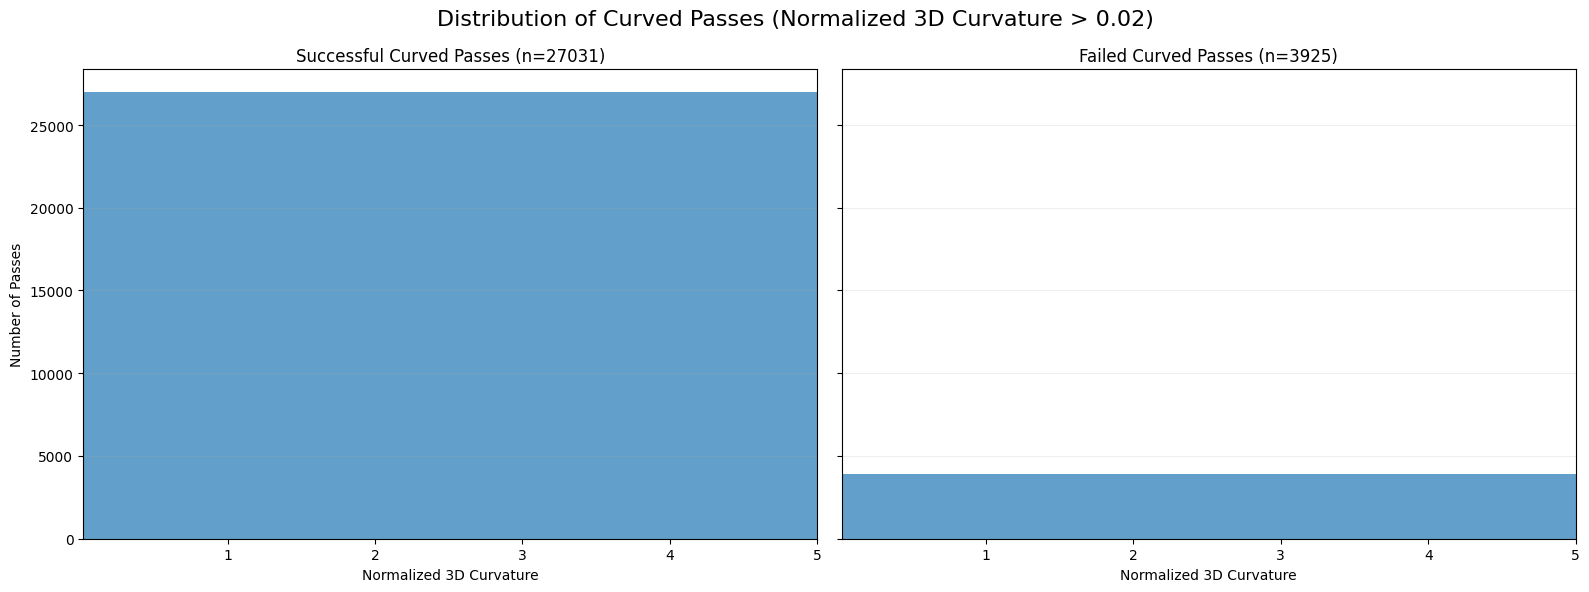

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/derived/3812_passes_with_curvature.csv")

threshold = 0.02


# ============================================================
# Select curved successful passes
# ============================================================

successful = df.loc[
    (df["pass_success"] == True)
    & (df["curvature_3d_normalized"] > threshold),
    "curvature_3d_normalized"
].dropna()


# ============================================================
# Select curved failed passes
# ============================================================

failed = df.loc[
    (df["pass_success"] == False)
    & (df["curvature_3d_normalized"] > threshold),
    "curvature_3d_normalized"
].dropna()


# ============================================================
# Shared bins for direct comparison
# ============================================================

all_values = pd.concat([
    successful,
    failed
])

bins = np.linspace(
    threshold,
    all_values.max(),
    31
)


# ============================================================
# Create separate histograms
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    sharey=True
)


# ============================================================
# Successful passes
# ============================================================

axes[0].hist(
    successful,
    bins=bins,
    alpha=0.7
)

axes[0].set_xlabel("Normalized 3D Curvature")
axes[0].set_ylabel("Number of Passes")

axes[0].set_title(
    f"Successful Curved Passes (n={len(successful)})"
)

axes[0].grid(
    axis="y",
    alpha=0.2
)


# ============================================================
# Failed passes
# ============================================================

axes[1].hist(
    failed,
    bins=bins,
    alpha=0.7
)

axes[1].set_xlabel("Normalized 3D Curvature")

axes[1].set_title(
    f"Failed Curved Passes (n={len(failed)})"
)

axes[1].grid(
    axis="y",
    alpha=0.2
)


# ============================================================
# Overall title
# ============================================================

fig.suptitle(
    f"Distribution of Curved Passes "
    f"(Normalized 3D Curvature > {threshold})",
    fontsize=16
)
axes[0].set_xlim(threshold, 5)
axes[1].set_xlim(threshold, 5)
plt.tight_layout()
plt.show()

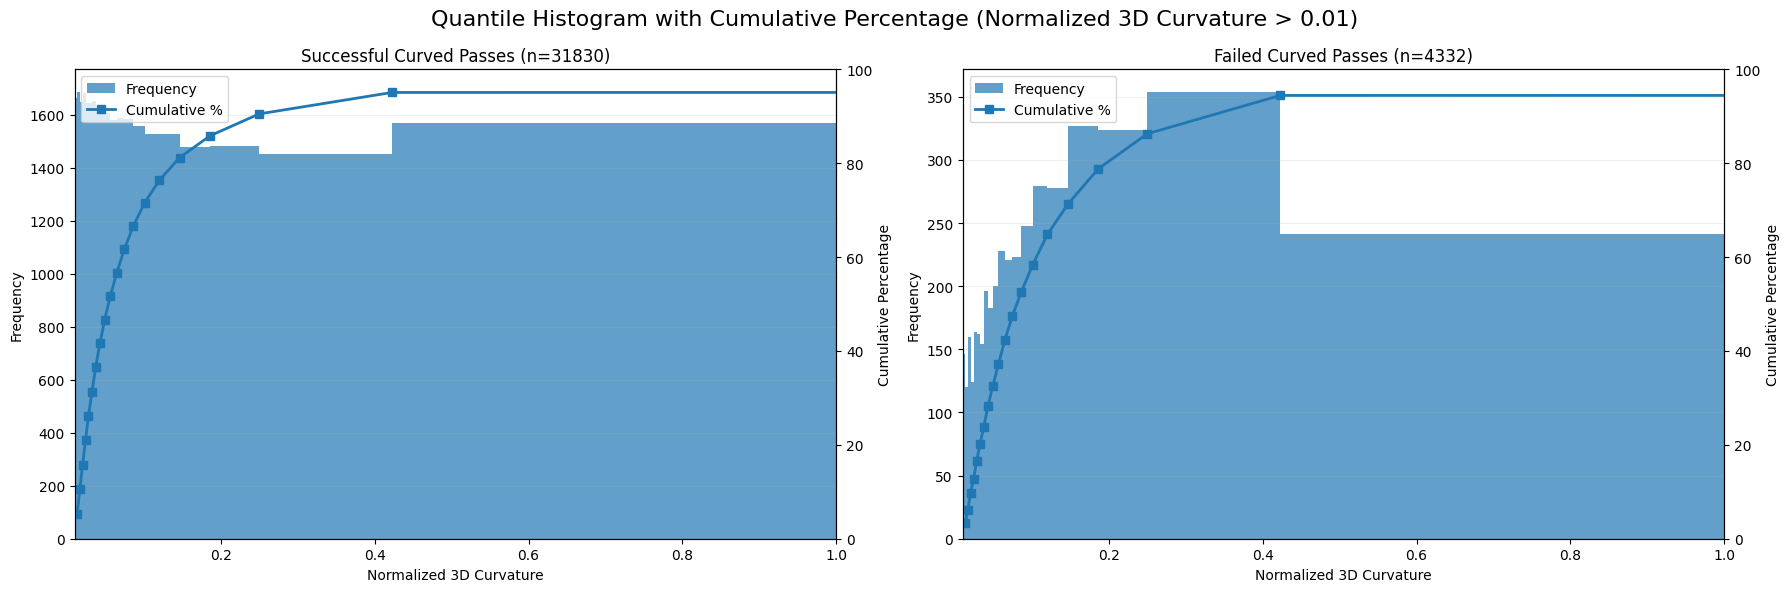

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Load data
# ============================================================

df = pd.read_csv("../data/derived/3812_passes_with_curvature.csv")

threshold = 0.01


# ============================================================
# Select curved successful and failed passes
# ============================================================

successful = df.loc[
    (df["pass_success"] == True)
    & (df["curvature_3d_normalized"] > threshold),
    "curvature_3d_normalized"
].dropna()


failed = df.loc[
    (df["pass_success"] == False)
    & (df["curvature_3d_normalized"] > threshold),
    "curvature_3d_normalized"
].dropna()


# ============================================================
# Create shared quantile bins from ALL curved passes
# ============================================================

all_values = pd.concat([
    successful,
    failed
])

n_bins = 20

quantiles = np.linspace(
    0,
    1,
    n_bins + 1
)

quantile_edges = np.quantile(
    all_values,
    quantiles
)

# Remove duplicate edges
quantile_edges = np.unique(
    quantile_edges
)

if len(quantile_edges) < 2:
    raise ValueError(
        "Not enough unique values to create quantile bins."
    )


# ============================================================
# Function:
# Quantile histogram + cumulative percentage
# ============================================================

def plot_quantile_histogram_with_cumulative(
    ax,
    values,
    bins,
    title
):

    # ========================================================
    # Calculate counts using the QUANTILE bins
    # ========================================================

    counts, edges = np.histogram(
        values,
        bins=bins
    )


    # ========================================================
    # Quantile histogram
    #
    # density=False because the cumulative percentage is based
    # directly on the number of passes in each quantile bin.
    # ========================================================

    ax.hist(
        values,
        bins=bins,
        alpha=0.7,
        label="Frequency"
    )

    ax.set_xlabel(
        "Normalized 3D Curvature"
    )

    ax.set_ylabel(
        "Frequency"
    )

    ax.set_title(
        title
    )

    ax.grid(
        axis="y",
        alpha=0.2
    )


    # ========================================================
    # Calculate cumulative percentage
    # ========================================================

    cumulative_percentage = (
        np.cumsum(counts)
        / counts.sum()
        * 100
    )


    # Use the UPPER edge of every bin.
    #
    # Example:
    # After the first bin, cumulative percentage corresponds
    # to the percentage of passes with curvature <= bins[1].
    # ========================================================

    cumulative_x = edges[1:]


    # ========================================================
    # Second Y-axis
    # ========================================================

    ax_cumulative = ax.twinx()

    ax_cumulative.plot(
        cumulative_x,
        cumulative_percentage,
        marker="s",
        linewidth=2,
        label="Cumulative %"
    )

    ax_cumulative.set_ylabel(
        "Cumulative Percentage"
    )

    ax_cumulative.set_ylim(
        0,
        100
    )


    # ========================================================
    # Combined legend
    # ========================================================

    handles_1, labels_1 = (
        ax.get_legend_handles_labels()
    )

    handles_2, labels_2 = (
        ax_cumulative.get_legend_handles_labels()
    )

    ax.legend(
        handles_1 + handles_2,
        labels_1 + labels_2,
        loc="upper left"
    )


# ============================================================
# Create separate quantile histograms
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 6)
)


# ============================================================
# Successful passes
# ============================================================

plot_quantile_histogram_with_cumulative(
    axes[0],
    successful,
    quantile_edges,
    f"Successful Curved Passes (n={len(successful)})"
)


# ============================================================
# Failed passes
# ============================================================

plot_quantile_histogram_with_cumulative(
    axes[1],
    failed,
    quantile_edges,
    f"Failed Curved Passes (n={len(failed)})"
)


# ============================================================
# Optional: limit visible curvature range
# ============================================================

for ax in axes:
    ax.set_xlim(
        threshold,
        1
    )


# ============================================================
# Overall title
# ============================================================

fig.suptitle(
    f"Quantile Histogram with Cumulative Percentage "
    f"(Normalized 3D Curvature > {threshold})",
    fontsize=16
)

plt.tight_layout()
plt.show()

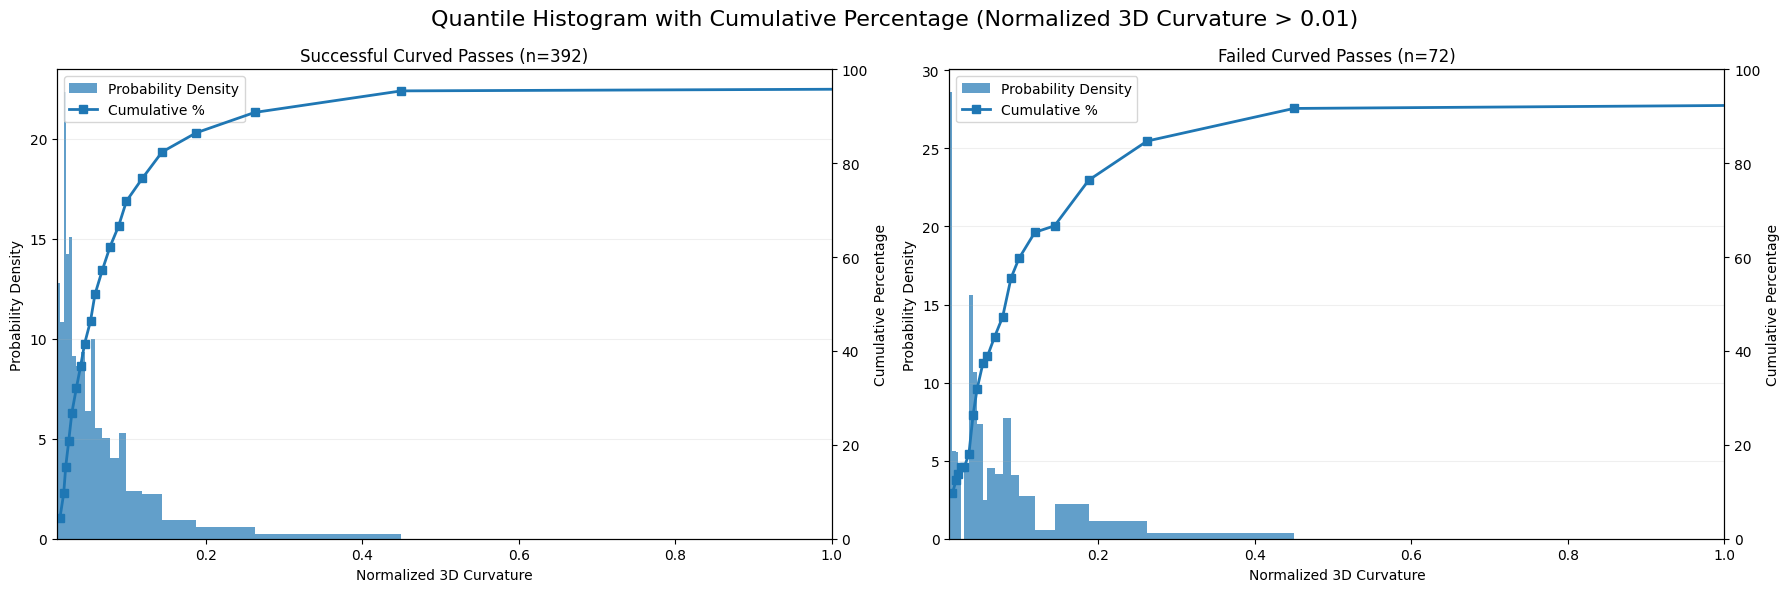


Quantile Bin Ranges:
Bin 01: [0.010388, 0.013784)
Bin 02: [0.013784, 0.018718)
Bin 03: [0.018718, 0.021229)
Bin 04: [0.021229, 0.025174)
Bin 05: [0.025174, 0.029064)
Bin 06: [0.029064, 0.034915)
Bin 07: [0.034915, 0.040244)
Bin 08: [0.040244, 0.045436)
Bin 09: [0.045436, 0.052995)
Bin 10: [0.052995, 0.058602)
Bin 11: [0.058602, 0.067853)
Bin 12: [0.067853, 0.077967)
Bin 13: [0.077967, 0.088754)
Bin 14: [0.088754, 0.098889)
Bin 15: [0.098889, 0.119182)
Bin 16: [0.119182, 0.144358)
Bin 17: [0.144358, 0.187971)
Bin 18: [0.187971, 0.262616)
Bin 19: [0.262616, 0.449983)
Bin 20: [0.449983, 7.712516)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Load data
# ============================================================

df = pd.read_csv("../data/derived/3812_passes_with_curvature.csv")

threshold = 0.01


# ============================================================
# Select curved successful passes
# ============================================================

successful = df.loc[
    (df["pass_success"] == True)
    & (df["curvature_3d_normalized"] > threshold),
    "curvature_3d_normalized"
].dropna()


# ============================================================
# Select curved failed passes
# ============================================================

failed = df.loc[
    (df["pass_success"] == False)
    & (df["curvature_3d_normalized"] > threshold),
    "curvature_3d_normalized"
].dropna()


# ============================================================
# Combine all curved passes
#
# Quantile edges are calculated from the combined distribution
# so both successful and failed passes use exactly the same
# curvature intervals.
# ============================================================

all_values = pd.concat([
    successful,
    failed
])


# ============================================================
# Create quantile bins
#
# 20 bins means approximately 5% of the combined population
# per bin.
# ============================================================

n_bins = 20

quantiles = np.linspace(
    0,
    1,
    n_bins + 1
)

quantile_edges = np.quantile(
    all_values,
    quantiles
)


# ============================================================
# Remove duplicate edges
#
# Required if multiple quantiles produce the same curvature
# value.
# ============================================================

quantile_edges = np.unique(
    quantile_edges
)

if len(quantile_edges) < 2:
    raise ValueError(
        "Not enough unique curvature values to create "
        "quantile bins."
    )


# ============================================================
# Function:
# Quantile histogram using probability density
# + cumulative percentage line
# ============================================================

def plot_quantile_histogram_with_cumulative(
    ax,
    values,
    bins,
    title
):

    # ========================================================
    # Calculate raw counts
    #
    # These are used ONLY for the cumulative percentage.
    # ========================================================

    counts, edges = np.histogram(
        values,
        bins=bins
    )


    # ========================================================
    # Quantile histogram
    #
    # density=True is important because quantile bins have
    # unequal numerical widths.
    #
    # The AREA of each bar represents the proportion of
    # observations in that bin.
    # ========================================================

    ax.hist(
        values,
        bins=bins,
        density=True,
        alpha=0.7,
        label="Probability Density"
    )

    ax.set_xlabel(
        "Normalized 3D Curvature"
    )

    ax.set_ylabel(
        "Probability Density"
    )

    ax.set_title(
        title
    )

    ax.grid(
        axis="y",
        alpha=0.2
    )


    # ========================================================
    # Calculate cumulative percentage
    # ========================================================

    cumulative_percentage = (
        np.cumsum(counts)
        / counts.sum()
        * 100
    )


    # ========================================================
    # Plot cumulative value at the upper edge of each bin
    # ========================================================

    cumulative_x = edges[1:]


    # ========================================================
    # Create secondary Y-axis
    # ========================================================

    ax_cumulative = ax.twinx()

    ax_cumulative.plot(
        cumulative_x,
        cumulative_percentage,
        marker="s",
        linewidth=2,
        label="Cumulative %"
    )

    ax_cumulative.set_ylabel(
        "Cumulative Percentage"
    )

    ax_cumulative.set_ylim(
        0,
        100
    )


    # ========================================================
    # Combine legends from both axes
    # ========================================================

    handles_1, labels_1 = (
        ax.get_legend_handles_labels()
    )

    handles_2, labels_2 = (
        ax_cumulative.get_legend_handles_labels()
    )

    ax.legend(
        handles_1 + handles_2,
        labels_1 + labels_2,
        loc="upper left"
    )


    return ax_cumulative


# ============================================================
# Create separate plots
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 6)
)


# ============================================================
# Successful curved passes
# ============================================================

plot_quantile_histogram_with_cumulative(
    axes[0],
    successful,
    quantile_edges,
    f"Successful Curved Passes (n={len(successful)})"
)


# ============================================================
# Failed curved passes
# ============================================================

plot_quantile_histogram_with_cumulative(
    axes[1],
    failed,
    quantile_edges,
    f"Failed Curved Passes (n={len(failed)})"
)


# ============================================================
# Set the visible curvature range
# ============================================================

for ax in axes:
    ax.set_xlim(
        threshold,
        1
    )


# ============================================================
# Overall title
# ============================================================

fig.suptitle(
    f"Quantile Histogram with Cumulative Percentage "
    f"(Normalized 3D Curvature > {threshold})",
    fontsize=16
)

plt.tight_layout()
plt.show()


# ============================================================
# Print quantile bin ranges
# ============================================================

print("\nQuantile Bin Ranges:")

for i in range(
    len(quantile_edges) - 1
):
    print(
        f"Bin {i + 1:02d}: "
        f"[{quantile_edges[i]:.6f}, "
        f"{quantile_edges[i + 1]:.6f})"
    )

In [ ]:
print(f"First bin range: {bins[0]:.6f} to {bins[1]:.6f}")

First bin range: 0.000000 to 0.257084


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/derived/3812_passes_with_curvature.csv")

curvature = df["curvature_3d_normalized"]

threshold = 0.06

# Define curved passes
curved = curvature > threshold

total_passes = curvature.notna().sum()
curved_passes = curved.sum()

successful = df["pass_success"] == True
failed = df["pass_success"] == False

successful_total = (successful & curvature.notna()).sum()
successful_curved = (successful & curved).sum()

failed_total = (failed & curvature.notna()).sum()
failed_curved = (failed & curved).sum()

print("=" * 60)
print("CURVED PASS STATISTICS")
print("=" * 60)

print(f"Threshold                  : > {threshold}")
print(f"Total passes               : {total_passes}")
print(f"Curved passes              : {curved_passes}")
print(
    f"Overall curved percentage  : "
    f"{100 * curved_passes / total_passes:.2f}%"
)

print("\n" + "-" * 60)

print(f"Successful passes          : {successful_total}")
print(f"Successful curved passes   : {successful_curved}")
print(
    f"Successful curved %        : "
    f"{100 * successful_curved / successful_total:.2f}%"
)

print("\n" + "-" * 60)

print(f"Failed passes              : {failed_total}")
print(f"Failed curved passes       : {failed_curved}")
print(
    f"Failed curved %            : "
    f"{100 * failed_curved / failed_total:.2f}%"
)

print("=" * 60)

CURVED PASS STATISTICS
Threshold                  : > 0.06
Total passes               : 524
Curved passes              : 227
Overall curved percentage  : 43.32%

------------------------------------------------------------
Successful passes          : 445
Successful curved passes   : 183
Successful curved %        : 41.12%

------------------------------------------------------------
Failed passes              : 79
Failed curved passes       : 44
Failed curved %            : 55.70%
